In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import ipywidgets as widgets
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

print("✅ All libraries loaded successfully.")



✅ All libraries loaded successfully.


In [2]:
# Load the dataset
try:
    df = pd.read_csv('healthcare_cloud_billing.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.to_period('M').astype(str)
    print(f"✅ Data loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Display first few rows
display(df.head())



✅ Data loaded successfully. Shape: (1200, 22)


,Billing ID,Hospital Name,Department Name,Service Type,Region,Usage Hours,Storage Used (GB),Monthly Cost,Date,Payment Status,...,CPU Usage %,Memory Usage %,Forecast Demand,Cost Center,Network Bandwidth (GB),Data Egress Cost ($),Carbon Footprint (kgCO2e),Security Alerts,Compliance Status,Month
0,INV-10020,Manipal Hospitals,Pediatrics,Storage,eu-west-1,379.14,4042.23,137.72,2023-01-01,Paid,...,14.05,89.92,132.09,CC-780,313.46,15.67,19.91,2,Compliant,2023-01
1,INV-10227,Max Healthcare,Cardiology,Security,us-west-2,702.71,43.42,106.27,2023-01-01,Paid,...,6.24,43.95,108.57,CC-115,459.99,23.00,22.64,0,Compliant,2023-01
2,INV-10652,Tata Memorial,IT Dept,Database,ap-southeast-1,231.12,234.74,59.04,2023-01-01,Paid,...,18.15,20.90,59.61,CC-833,241.51,12.08,10.27,0,Compliant,2023-01
3,INV-10798,Narayana Health,Research,Networking,ap-southeast-1,351.52,93.69,54.60,2023-01-01,Paid,...,14.92,71.27,60.54,CC-304,336.57,16.83,17.33,0,Compliant,2023-01
4,INV-11072,Christian Medical College,Oncology,Storage,ap-south-1,633.84,3818.74,171.45,2023-01-01,Pending,...,1.04,11.75,173.69,CC-861,229.45,11.47,34.56,0,Compliant,2023-01


In [3]:
service_costs = df.groupby('Service Type')['Monthly Cost'].sum().reset_index()
fig1 = px.pie(service_costs, values='Monthly Cost', names='Service Type', hole=0.3,
             title='Cloud Service Cost Distribution', color_discrete_sequence=px.colors.sequential.Plasma)
fig1.update_layout(template='plotly_dark')
fig1.show()



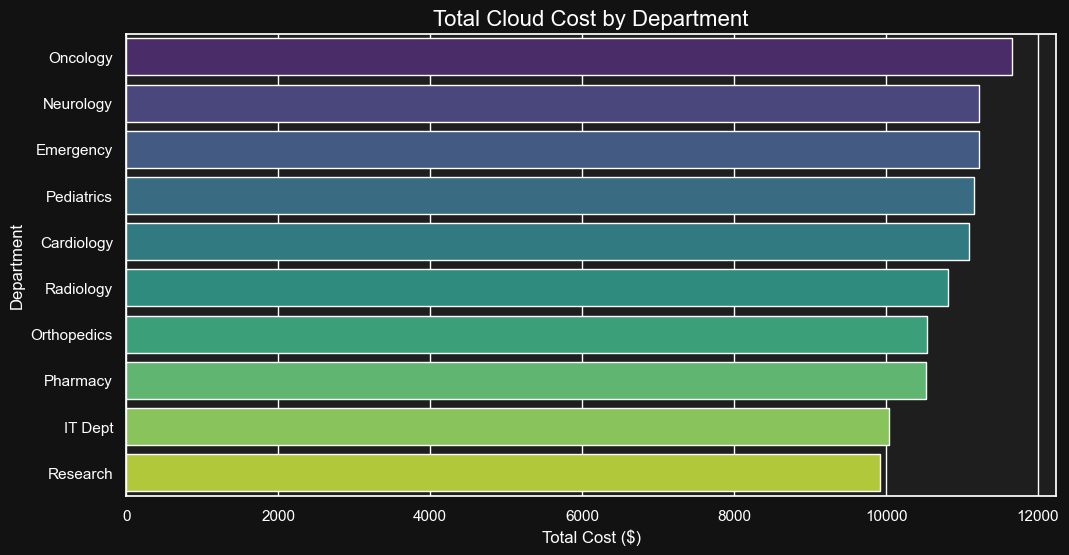

In [4]:
dept_costs = df.groupby('Department Name')['Monthly Cost'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Monthly Cost', y='Department Name', data=dept_costs, palette='viridis')
plt.title('Total Cloud Cost by Department', fontsize=16, color='white')
plt.xlabel('Total Cost ($)', color='white')
plt.ylabel('Department', color='white')
plt.show()



In [5]:
monthly_trend = df.groupby('Month')['Monthly Cost'].sum().reset_index()
fig3 = px.line(monthly_trend, x='Month', y='Monthly Cost', markers=True, 
               title='Monthly Cloud Cost Trend', line_shape='spline')
fig3.update_traces(line_color='#00ff99', line_width=3, marker=dict(size=8, color='white'))
fig3.update_layout(template='plotly_dark', xaxis_title='Month', yaxis_title='Cost ($)')
fig3.show()



In [6]:
vendor_share = df.groupby('Vendor Name')['Monthly Cost'].sum().reset_index()
fig4 = px.pie(vendor_share, values='Monthly Cost', names='Vendor Name', hole=0.5,
              title='Cloud Provider Market Share', color_discrete_sequence=['#ff9900', '#0078d4', '#ea4335'])
fig4.update_layout(template='plotly_dark')
fig4.show()



In [7]:
df['Year'] = df['Date'].dt.year
annual_expense = df.groupby('Year')['Monthly Cost'].sum().reset_index()
fig5 = px.bar(annual_expense, x='Year', y='Monthly Cost', title='Annual Cloud Expense', text_auto='.2s', color='Monthly Cost', color_continuous_scale=px.colors.sequential.Magma)
fig5.update_layout(template='plotly_dark')
fig5.show()


## 3. Advanced Cloud Cost Visualizations

This section visualizes cloud spending metrics using interactive Plotly charts, showing cumulative spend, budget variance, and multi-cloud breakdown.

### 3.1 Hospital Cost Comparison

In [8]:
hospital_costs = df.groupby('Hospital Name')['Monthly Cost'].sum().sort_values(ascending=False).reset_index()
fig_hosp = px.bar(hospital_costs, x='Hospital Name', y='Monthly Cost', color='Hospital Name',
                  title='Hospital Cost Comparison', text_auto='.2s')
fig_hosp.update_layout(template='plotly_dark')
fig_hosp.show()


### 3.2 Cumulative Cloud Spend Growth

In [9]:
df_sorted = df.sort_values('Date')
monthly_sum = df_sorted.groupby('Month')['Monthly Cost'].sum().reset_index()
monthly_sum['Cumulative Cost'] = monthly_sum['Monthly Cost'].cumsum()
monthly_sum['Date'] = pd.to_datetime(monthly_sum['Month'] + '-01')

fig_cum = px.area(monthly_sum, x='Date', y='Cumulative Cost', 
                  title='Cumulative Cloud Cost Growth over Time',
                  color_discrete_sequence=['#ff4b4b'])
fig_cum.update_layout(template='plotly_dark')
fig_cum.show()


### 3.5 Outlier Detection in Service Costs

In [12]:
fig_box = px.box(df, x='Service Type', y='Monthly Cost', color='Service Type',
                 title='Outlier Detection in Service Costs',
                 color_discrete_sequence=px.colors.sequential.Magma)
fig_box.update_layout(template='plotly_dark', showlegend=False)
fig_box.show()


### 3.6 Budget Variance Analysis

In [13]:
dept_variance = df.groupby('Department Name')['Monthly Cost'].sum().reset_index()
np.random.seed(42)
dept_variance['Allocated Budget'] = dept_variance['Monthly Cost'] * np.random.uniform(0.8, 1.2, len(dept_variance))
dept_variance['Variance'] = dept_variance['Allocated Budget'] - dept_variance['Monthly Cost']

import plotly.graph_objects as go
fig_var = go.Figure()
fig_var.add_trace(go.Bar(
    x=dept_variance['Department Name'], 
    y=dept_variance['Variance'],
    marker_color=np.where(dept_variance['Variance'] < 0, 'red', 'green'),
    name='Variance'
))
fig_var.update_layout(
    title='Budget Variance Analysis (Positive = Under Budget, Negative = Over Budget)',
    template='plotly_dark', 
    yaxis_title='Variance ($)'
)
fig_var.show()


## 4. AI & Predictive Analytics

### 4.1 Cost Prediction (Linear Regression)

In [14]:
from sklearn.linear_model import LinearRegression

ml_df = df.groupby('Date')['Monthly Cost'].sum().reset_index()
ml_df['Day_Index'] = (ml_df['Date'] - ml_df['Date'].min()).dt.days

X = ml_df[['Day_Index']]
y = ml_df['Monthly Cost']

model = LinearRegression()
model.fit(X, y)

# Predict next 30 days
max_day = X['Day_Index'].max()
future_days = np.array([[max_day + i] for i in range(1, 31)])
future_preds = model.predict(future_days)
predicted_next_month_cost = future_preds.sum()
print(f"Predicted Cloud Spend (Next 30 Days): ${predicted_next_month_cost:,.2f}")

# Plot regression trend
fig_reg = go.Figure()
fig_reg.add_trace(go.Scatter(x=ml_df['Date'], y=y, mode='markers', name='Actual Costs', marker=dict(color='#00F0FF', opacity=0.6)))

future_dates = [ml_df['Date'].max() + pd.Timedelta(days=i) for i in range(1, 31)]
all_dates = pd.concat([ml_df['Date'], pd.Series(future_dates)])
all_days = np.array([[day] for day in range(max_day + 31)])
all_preds = model.predict(all_days)

fig_reg.add_trace(go.Scatter(x=all_dates, y=all_preds, mode='lines', name='Trend / Forecast', line=dict(color='#FF0055', width=3)))
fig_reg.update_layout(title='Cost Trend Analysis & ML Prediction', template='plotly_dark')
fig_reg.show()


Predicted Cloud Spend (Next 30 Days): $9,383.42


## 5. Cost Optimization Actions

In [16]:
# Underutilized Resources Analysis
unused_resources = df[(df['Usage Hours'] < 50) & (df['Monthly Cost'] > 500)]
print(f"💡 Found {len(unused_resources)} underutilized resources with low usage (<50 hours) but high cost (>$500).")
if not unused_resources.empty:
    display(unused_resources[['Billing ID', 'Hospital Name', 'Department Name', 'Service Type', 'Monthly Cost', 'Usage Hours']])
else:
    print("✅ No significantly underutilized resources detected.")


💡 Found 0 underutilized resources with low usage (<50 hours) but high cost (>$500).
✅ No significantly underutilized resources detected.


In [17]:
region_costs = df.groupby('Region')['Monthly Cost'].sum().sort_values(ascending=False).reset_index()
fig5 = px.bar(region_costs, x='Region', y='Monthly Cost', title='Cloud Cost by Region', color='Monthly Cost', color_continuous_scale=px.colors.sequential.Teal)
fig5.update_layout(template='plotly_dark')
fig5.show()
